This is a notebook for writing down my thoughts for the article Reconstructing Patchy Reionization from the Cosmic Microwave Background

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from scipy.interpolate import interp1d

import camb
from camb import model

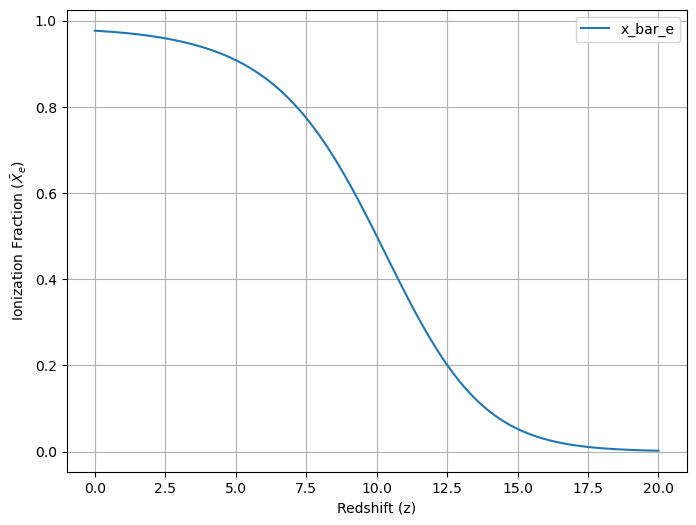

In [2]:
def x_bar_e(z, y_re=5.0, delta_y=19.0):
    """
    Calculate the average ionization fraction of hydrogen in a plasma given the redshift z.

    Parameters:
    z (float): Redshift value.
    y_re (float): Reference value.
    delta_y (float): Width of the distribution.

    Returns:
    float: The average ionization fraction of hydrogen.
    """
    def y(z):
        y = (1 + z) ** (3/2)
        return y

    x_bar_e = 0.5 * (1 - np.tanh((y(z) - y_re) / delta_y))
    return x_bar_e

z = np.linspace(0, 20, 100)  # Redshift range from 0 to 20

plt.figure(figsize=(8, 6))
plt.plot(z, x_bar_e(z, y_re=36.5, delta_y=19.0), label=f'x_bar_e')

plt.xlabel("Redshift (z)")
plt.ylabel("Ionization Fraction ($\\bar{X}_e$)")

plt.legend()
plt.grid()
plt.show()  

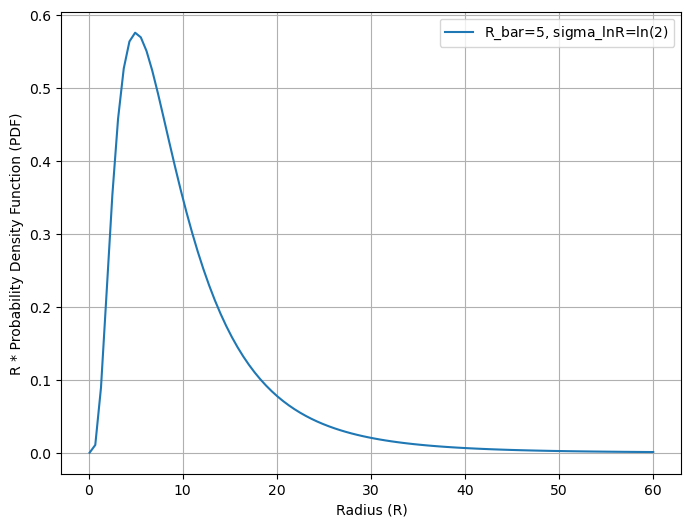

In [3]:
def P(R, R_bar=5, sigma_lnR=np.log(2)):
    """
    Calculate the the bubble radius distribution P(R) of the H II region.

    Parameters:
    R_bar (float): characteristic size, default = 5.0
    R (float or array-like): Radius values.
    sigma_lnR (float): width of the distribution, default = ln(2)

    Returns:
    float or array-like: The PDF evaluated at the given radius values.
    """
    # Calculate the PDF using the log-normal distribution formula
    P_R = (1 / (R * sigma_lnR * np.sqrt(2 * np.pi))) * np.exp(- (np.log(R) - np.log(R_bar))**2 / (2 * sigma_lnR**2))
    return P_R


#### Parameter Set ####
R_max = 60 # Max radius for integrations and ploting
R_bar = 5  # characteristic size
sigma_lnR = np.log(2)  # width of the distribution
b = 1.0 # bubble bias, for simplicity, the model assumes it to be a constant


R_values = np.linspace(0.1, R_max, 100)

plt.figure(figsize=(8, 6))
plt.plot(R_values, R_values * P(R_values, R_bar, sigma_lnR), label=f'R_bar={R_bar}, sigma_lnR=$\\ln(2)$')

plt.xlabel("Radius (R)")
plt.ylabel("R * Probability Density Function (PDF)")

plt.legend()
plt.grid()
plt.show()  

In [4]:
# Now get matter power spectra and sigma8 at redshift 0 and 0.8
# parameters can all be passed as a dict as above, or you can call
# separate functions to set up the parameter object
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)
# Note non-linear corrections couples to smaller scales than you want
pars.set_matter_power(
    redshifts=[6,7,8,10],
    kmax=2.0
)

# Linear spectra
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh,z,Pk = results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=1,
    npoints=300
)

# Interpolate matter power spectrum at target redshift (z=8 -> index 2)
z_index = 2  # z=8 corresponds to the third redshift in [6,7,8,10]
P_matter_interp = interp1d(kh, Pk[z_index, :], kind='linear', fill_value='extrapolate')


Note: redshifts have been re-sorted (earliest first)


In [5]:
def V(R):
    """
    The volume function for the ionized bubble, which is assumed as a sphere.
    """
    return 4/3 * np.pi * R ** 3

def V_bar(R_bar=5, sigma_lnR=np.log(2)):
    """
    Expected volume with weight function P(R) for different bubble radius R
    """

    def f(R):
        return P(R, R_bar, sigma_lnR)*V(R)
    
    Int, error = integrate.quad(
        f, 
        0, 
        R_max
        )
    return Int

def W(k, R):
    """
    The Fourier transform of a real-space tophat window function with radius R

    Parameters:
    k = ell/chi:  ??
    R (float or array-like): Radius values.
    """
    kR = np.asarray(k) * np.asarray(R)
    # Handle kR -> 0 limit: W -> 1
    # Use np.where to avoid division by zero
    with np.errstate(invalid='ignore', divide='ignore'):
        W_val = np.where(np.abs(kR) < 1e-10, 1.0,
                         3/(kR)**3 * (np.sin(kR) - kR * np.cos(kR)))
    return W_val


# === F(k): single-k scalar version ===
def F_single(k):
    """
    Compute F(k) for a single scalar k using numerical integration.
    """
    def f(R):
        return P(R) * (V(R) * W(k, R))**2
    
    Int_F, error_F = integrate.quad(
        f,
        0,
        R_max
    )
    
    V_b = V_bar()
    F_val = Int_F/V_b

    return F_val

# Vectorize: allows F to accept array k
F_vec = np.vectorize(F_single)

# Alias: F now works for both scalar and array k
def F(k):
    return F_vec(k)


# === I(k): single-k scalar version ===
def I_single(k):
    """
    Compute I(k) for a single scalar k using numerical integration.
    """    
    def f(R):
        return P(R) * V(R) * W(k, R)
    
    Int_I, error_I = integrate.quad(
        f,
        0,
        R_max
    )
    V_b = V_bar()
    
    I_val = b * Int_I/V_b

    return I_val

# Vectorize: allows I to accept array k
I_vec = np.vectorize(I_single)

def I(k):
    return I_vec(k)


# # === G(k): single-k version ===
# def G_single(k):
#     """
#     Compute G(k) for a single scalar k.
    
#     NOTE: The inner integrand uses P_matter(q) from CAMB.
#     This is a double integral (dmu dkp) and will be slow.
#     """

#     def integrand_mu(mu, kp):
#         q = np.sqrt(k**2 + kp**2 - 2*k*kp*mu)
#         return P_matter_interp(q)

#     def integrand_kp(kp):
#         mu_integral = integrate.quad(
#             lambda mu: integrand_mu(mu, kp),
#             -1, 1
#         )[0]
#         return kp**2 * F_single(kp) * mu_integral

#     result = integrate.quad(
#         integrand_kp,
#         0,
#         kh[-1]
#     )[0]

#     return result/(4*np.pi**2)


# # Vectorize: allows G to accept array k
# G_vec = np.vectorize(G_single)

# def G(k):
#     return G_vec(k)


In [6]:
k_grid=np.logspace(-3,1,500)

F_grid=np.array(
    [F(k) for k in k_grid]
)

F_interp = interp1d(k_grid, F_grid, kind='linear', fill_value='extrapolate')

kp_grid=np.logspace(-3,1,300)

mu_grid=np.linspace(-1,1,100)

def G_fast(k):

    total_list = []

    for kp in kp_grid:

        q=np.sqrt(
            k[:, np.newaxis]**2
            +
            kp**2
            -
            2*k[:, np.newaxis]*kp*mu_grid
        )


        P_mu=np.trapz(
            P_matter_interp(q),
            mu_grid,
            axis=-1
        )


        total_list.append(
            kp**2
            *
            F_interp(kp)
            *
            P_mu
        )

    total = np.array(total_list)

    return (
        np.trapz(
            total,
            kp_grid,
            axis=0
        )
        /(2*np.pi)**2
    )

/tmp/ipykernel_8885/2569556780.py:47: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Int_F, error_F = integrate.quad(


In [7]:
def P_1b(k, x_e):
    """
    1-bubble term of the ionization power spectrum.
    """
    F_val = F(k)
    G_val = G_fast(k)

    P1_val = x_e * (1 - x_e) * (F_val + G_val)

    return P1_val

def P_2b(k, x_e):
    """
    2-bubble term of the ionization power spectrum.
    """
    I_val = I(k)
    P_val = P_matter_interp(k)  # matter power spectrum from CAMB

    P2_val = ((1-x_e) * np.log(1-x_e) * I_val-x_e)**2 * P_val

    return P2_val

def P_DeltaXe(k, x_e):
    """
    Total power spectrum = 1-bubble + 2-bubble terms
    """
    P1_val = P_1b(k, x_e)
    P2_val = P_2b(k, x_e)

    return P1_val + P2_val


In [8]:
# --- Test: plot only the 1-bubble term first (G(k) double integral is slow) ---
# If you want a quick test, try P_1b first:

plt.figure(figsize=(8, 6))
k_test = np.logspace(-2, 0, 30)  # fewer points for faster test
plt.loglog(k_test, P_DeltaXe(k_test, x_bar_e(8)), label=f'P_1b at z=8')
plt.xlabel('k [1/Mpc]')
plt.ylabel('P_1b')
plt.legend()
plt.grid()
plt.show()


# --- Full plot (slow due to G(k) double integral) ---
# plt.figure(figsize=(8, 6))
# plt.plot(kh, P_DeltaXe(kh, x_bar_e(8)), label=f'P_2b at z=8')
# plt.xlabel('k')
# plt.ylabel('P_DeltaXe')
# plt.title('P_DeltaXe vs k')
# plt.legend()
# plt.grid()
# plt.show()

ValueError: operands could not be broadcast together with shapes (30,) (100,) 

<Figure size 800x600 with 0 Axes>